# 05 — Data Loading for SABR Calibration

**Inputs on disk** (already downloaded):

| Source | Files | Coverage |
|---|---|---|
| FRED daily Treasury yields | `DGS1MO.csv`, `DGS3MO.csv`, `DGS6MO.csv`, `DGS1.csv`, `DGS2.csv` | 2014-01 → 2023-12 |
| SPY EOD options (optionsdx) | `spy_eod_YYYYMM.txt` × 120 | 2014-01 → 2023-12 |
| QQQ EOD options (optionsdx) | `qqq_eod_YYYYMM.txt` × 120 | 2014-01 → 2023-12 |

**Goal.** Produce, for any `(ticker, trade_date, expiry)`, a clean smile DataFrame `(K, K/F, T, F, r, sigma_mkt, ...)` that Module 4 can feed into `scipy.optimize.least_squares`.

**Sub-steps.**
1. FRED yield curves — plot and verify linear interpolation.
2. Load a single month of SPY options; inspect the filtered frame.
3. Build one smile — $F$ via put-call parity, OTM-only filter.
4. Load all 10 years of SPY + QQQ; cache to parquet.
5. Smile-panel: the same expiry on several dates → sanity check for    Module 5 (dynamics comparison).
6. Export a curated list of calibration dates for Module 4.

In [1]:
import sys, os, glob, time
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    'figure.figsize': (8, 4.5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'Data'))
CACHE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'cache'))
os.makedirs(CACHE_DIR, exist_ok=True)
print('DATA_DIR :', DATA_DIR)
print('CACHE_DIR:', CACHE_DIR)

from src.data_loader import (
    load_fred_yields, interpolate_yield,
    load_options_file, load_options,
    extract_forward, build_smile, FRED_TENORS,
)


DATA_DIR : <repo>/Data
CACHE_DIR: <repo>/cache


---
## 1. FRED Treasury yield curves

In [2]:
rates = load_fred_yields(DATA_DIR)
rates = rates.ffill()   # carry yields over US holidays
print(f'shape = {rates.shape}')
print(f'date range = {rates.index.min().date()} -> {rates.index.max().date()}')
rates.head()

shape = (2607, 5)
date range = 2014-01-02 -> 2023-12-29


,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2
date,,,,,
2014-01-02,0.0001,0.0007,0.0009,0.0013,0.0039
2014-01-03,0.0002,0.0007,0.0010,0.0013,0.0041
2014-01-06,0.0001,0.0005,0.0008,0.0012,0.0040
2014-01-07,0.0001,0.0004,0.0008,0.0013,0.0040
2014-01-08,0.0000,0.0005,0.0008,0.0013,0.0043


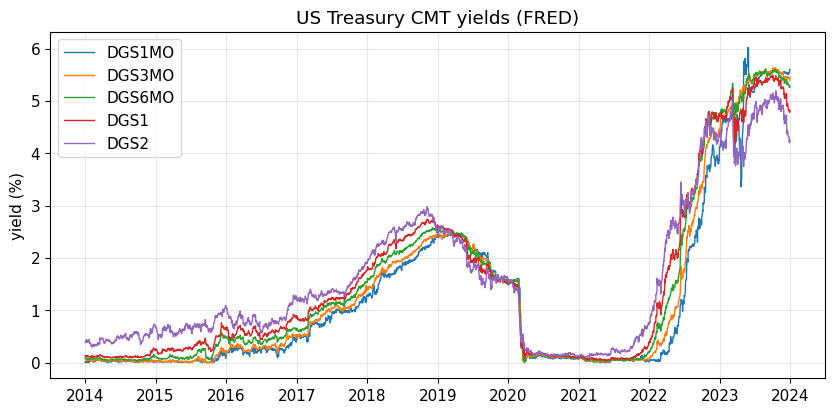

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for col in rates.columns:
    ax.plot(rates.index, rates[col]*100, label=col, lw=1)
ax.set_ylabel('yield (%)')
ax.set_title('US Treasury CMT yields (FRED)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(loc='upper left'); plt.show()

### Yield-curve snapshots — interpolation sanity check
Plot the observed (tenor, yield) points on a handful of dates and the linearly interpolated curve used by `interpolate_yield`.

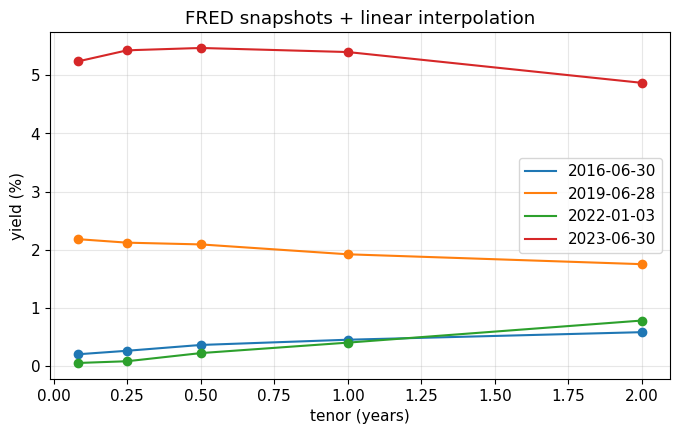

In [4]:
import numpy as np
taus_fine = np.linspace(1/12, 2.0, 60)
sample_dates = ['2016-06-30', '2019-06-28', '2022-01-03', '2023-06-30']

fig, ax = plt.subplots(figsize=(8, 4.5))
for d in sample_dates:
    row = rates.loc[d].dropna()
    tenors = np.array([FRED_TENORS[c] for c in row.index])
    yields = row.values * 100
    curve = [interpolate_yield(rates, d, t)*100 for t in taus_fine]
    p = ax.plot(taus_fine, curve, label=d)[0]
    ax.scatter(tenors, yields, color=p.get_color(), zorder=3)
ax.set_xlabel('tenor (years)'); ax.set_ylabel('yield (%)')
ax.set_title('FRED snapshots + linear interpolation')
ax.legend(); plt.show()

---
## 2. Load one month of SPY options

`load_options_file` parses the optionsdx format, normalises the bracketed header, coerces numerics, and applies three filters:
* DTE ∈ [5, 365] (drop 0-DTE row at top of file; drop ultra-long)
* |STRIKE_DISTANCE_PCT| ≤ 0.30 (keep ±30 % of spot)
* strike > 0.

In [5]:
t0 = time.time()
jan22 = load_options_file(os.path.join(DATA_DIR, 'spy', 'spy_eod_202201.txt'))
print(f'rows kept: {len(jan22):,}   ({time.time()-t0:.2f}s)')
jan22.head()

rows kept: 68,449   (0.73s)


,QUOTE_DATE,UNDERLYING_LAST,EXPIRE_DATE,DTE,C_IV,C_BID,C_ASK,C_VOLUME,P_IV,P_BID,P_ASK,P_VOLUME,STRIKE,STRIKE_DISTANCE_PCT
0,2022-01-03,477.77,2022-01-10,7.0,NaN,107.58,107.91,0.0,0.53990,0.00,0.01,82.0,370.0,0.226
1,2022-01-03,477.77,2022-01-10,7.0,NaN,102.42,103.00,0.0,0.54317,0.01,0.01,2.0,375.0,0.215
2,2022-01-03,477.77,2022-01-10,7.0,NaN,97.43,97.99,0.0,0.51508,0.01,0.01,0.0,380.0,0.205
3,2022-01-03,477.77,2022-01-10,7.0,NaN,92.43,93.01,0.0,0.50498,0.01,0.02,212.0,385.0,0.194
4,2022-01-03,477.77,2022-01-10,7.0,NaN,87.58,87.91,NaN,0.47836,0.01,0.02,1.0,390.0,0.184


In [6]:
# what trade-dates and DTE values exist?
print('trade dates:', jan22['QUOTE_DATE'].dt.date.unique()[:5], '...')
print('num trade dates in month:', jan22['QUOTE_DATE'].nunique())
print('DTEs present:', sorted(jan22['DTE'].unique())[:15], '...')
print('strike coverage (pct of spot):',
      f"{jan22['STRIKE_DISTANCE_PCT'].min():+.3f}",
      f"{jan22['STRIKE_DISTANCE_PCT'].max():+.3f}")

trade dates: [datetime.date(2022, 1, 3) datetime.date(2022, 1, 4)
 datetime.date(2022, 1, 5) datetime.date(2022, 1, 6)
 datetime.date(2022, 1, 7)] ...
num trade dates in month: 21
DTEs present: [np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0)] ...
strike coverage (pct of spot): +0.000 +0.300


---
## 3. Build one smile — Jan 3 2022, 30-day expiry

`build_smile` does four things:
1. Slice to the chosen `(trade_date, DTE)`.
2. Compute $T$ in years, interpolate $r$ from the yield curve.
3. Extract the implied forward $F$ via put-call parity at the    strike with the smallest $|C-P|$.
4. Keep only the **OTM side** (puts for $K<F$, calls for $K>F$)    with bid ≥ 5 ¢ — the liquid part of the smile.

In [7]:
smile = build_smile(jan22, rates, trade_date='2022-01-03', dte=30)
meta = smile.attrs
print(f"F = {meta['F']:.3f},  T = {meta['expire_dte']:.1f} days,  r = {meta['r']*100:.3f}%")
print(f'{len(smile)} strikes retained')
smile.head()

F = 477.830,  T = 30.0 days,  r = 0.050%
53 strikes retained


,STRIKE,K_over_F,T,F,r,SIGMA_MKT,MID,BID,ASK,OPTION
0,385.0,0.805726,0.082136,477.829993,0.0005,0.35778,0.30,0.29,0.31,P
1,390.0,0.816190,0.082136,477.829993,0.0005,0.34375,0.33,0.32,0.34,P
2,395.0,0.826654,0.082136,477.829993,0.0005,0.32923,0.36,0.35,0.37,P
3,400.0,0.837118,0.082136,477.829993,0.0005,0.31676,0.40,0.39,0.41,P
4,405.0,0.847582,0.082136,477.829993,0.0005,0.30244,0.44,0.43,0.45,P


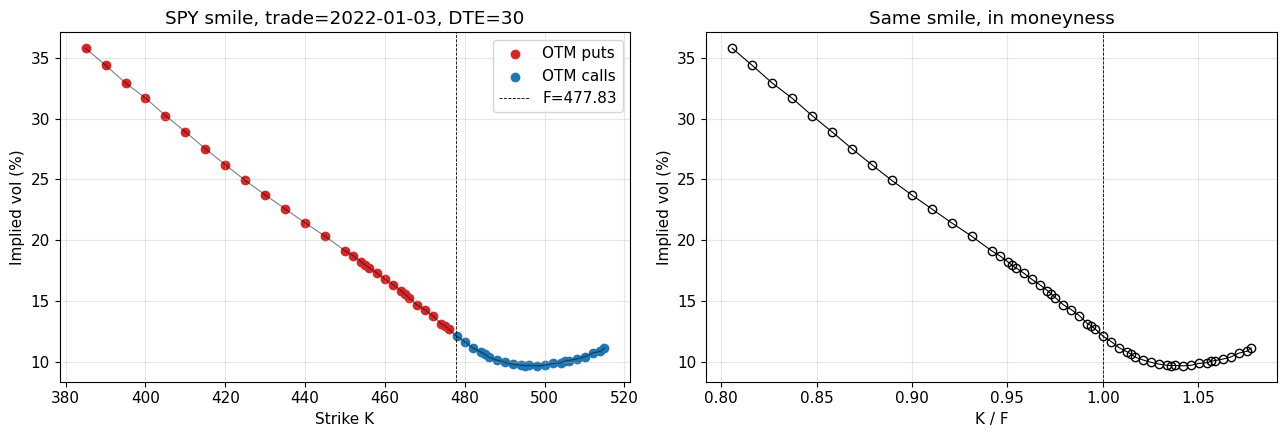

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
mask_p = smile['OPTION'] == 'P'
mask_c = smile['OPTION'] == 'C'
ax[0].plot(smile['STRIKE'], smile['SIGMA_MKT']*100, 'k-', lw=0.8, alpha=0.5)
ax[0].scatter(smile.loc[mask_p, 'STRIKE'], smile.loc[mask_p, 'SIGMA_MKT']*100,
              color='C3', label='OTM puts')
ax[0].scatter(smile.loc[mask_c, 'STRIKE'], smile.loc[mask_c, 'SIGMA_MKT']*100,
              color='C0', label='OTM calls')
ax[0].axvline(meta['F'], color='k', lw=0.6, ls='--', label=f"F={meta['F']:.2f}")
ax[0].set_xlabel('Strike K'); ax[0].set_ylabel('Implied vol (%)')
ax[0].set_title(f"SPY smile, trade={smile.attrs['trade_date'].date()}, DTE={meta['expire_dte']:.0f}")
ax[0].legend()

ax[1].plot(smile['K_over_F'], smile['SIGMA_MKT']*100, 'ko-', lw=0.8, mfc='none')
ax[1].axvline(1.0, color='k', lw=0.6, ls='--')
ax[1].set_xlabel('K / F'); ax[1].set_ylabel('Implied vol (%)')
ax[1].set_title('Same smile, in moneyness')
plt.tight_layout(); plt.show()

---
## 4. Load 10-year history for SPY + QQQ and cache to parquet

The full optionsdx dump is ~12 M rows per ticker before filtering, but only 4-5 M after the 30 %-moneyness window.  We cache the filtered frame to parquet so subsequent notebooks reload in a few seconds instead of ~1 min.

In [9]:
def cache_ticker(ticker):
    cache = os.path.join(CACHE_DIR, f'{ticker}_options_filtered.parquet')
    if os.path.exists(cache):
        df = pd.read_parquet(cache)
        print(f'[{ticker}] loaded cached parquet  rows={len(df):,}')
    else:
        t0 = time.time()
        df = load_options(ticker, DATA_DIR)
        df.to_parquet(cache)
        print(f'[{ticker}] built+cached  rows={len(df):,}  ({time.time()-t0:.1f}s)')
    return df

spy = cache_ticker('spy')
qqq = cache_ticker('qqq')

[spy] built+cached  rows=5,281,485  (84.8s)


[qqq] built+cached  rows=3,547,089  (48.2s)


In [10]:
# quick sanity: coverage per year
def cov_by_year(df, name):
    g = (df.assign(year=df['QUOTE_DATE'].dt.year)
           .groupby('year').agg(
                trade_days=('QUOTE_DATE', 'nunique'),
                rows=('STRIKE', 'count'),
                max_dte=('DTE', 'max'),
          ))
    g['ticker'] = name
    return g

pd.concat([cov_by_year(spy, 'SPY'), cov_by_year(qqq, 'QQQ')])

,trade_days,rows,max_dte,ticker
year,,,,
2014,250,268199,365.0,SPY
2015,252,302064,365.0,SPY
2016,251,338468,365.0,SPY
2017,250,377691,365.0,SPY
2018,252,493927,365.0,SPY
2019,248,514766,365.0,SPY
2020,250,755034,365.0,SPY
2021,252,876457,365.0,SPY
2022,256,761301,365.0,SPY


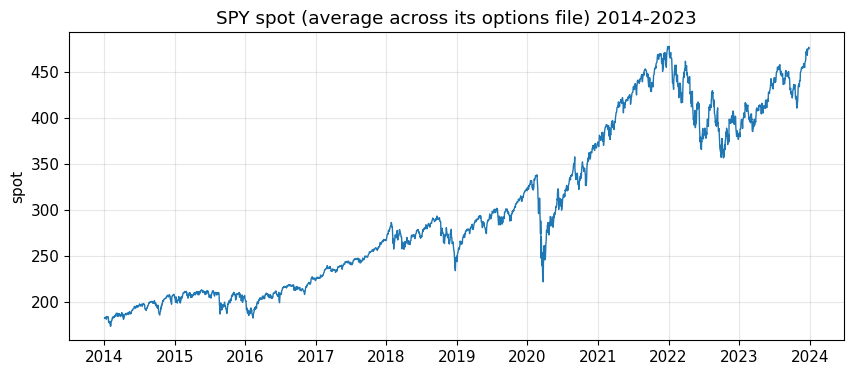

In [11]:
# SPY underlying price over the full sample
daily_spot = (spy.groupby('QUOTE_DATE')['UNDERLYING_LAST']
                 .mean().sort_index())
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(daily_spot.index, daily_spot.values, lw=1)
ax.set_title('SPY spot (average across its options file) 2014-2023')
ax.set_ylabel('spot')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.show()

---
## 5. Smile panel across several dates

Pick the same nominal DTE (30 days) on a grid of trade dates spanning several volatility regimes (Brexit, Covid, 2022 drawdown, post-ZIRP). This panel is the key input to **Module 5**: showing that the smile really does move *with the market* — the motivation for SABR over Local-Vol.

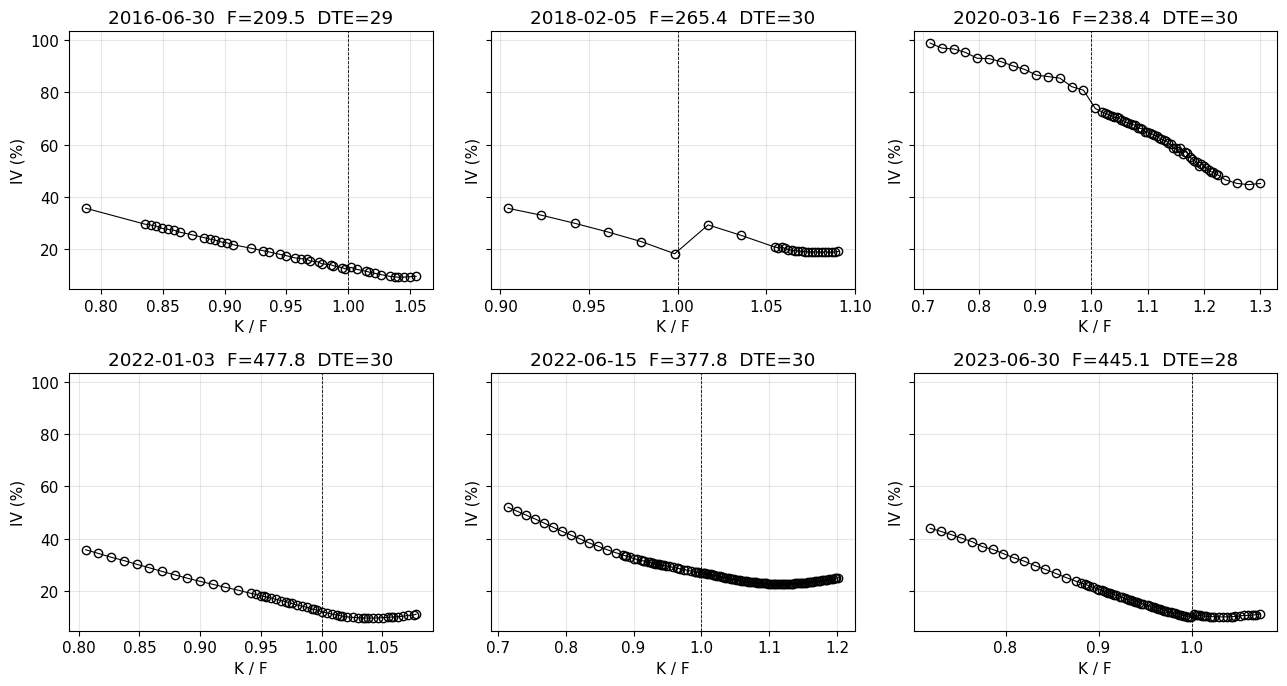

In [12]:
panel_dates = ['2016-06-30', '2018-02-05', '2020-03-16',
               '2022-01-03', '2022-06-15', '2023-06-30']

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True)
for ax, d in zip(axes.flat, panel_dates):
    try:
        sm = build_smile(spy, rates, d, dte=30)
    except ValueError as e:
        ax.set_title(f'{d}: {e}'); continue
    ax.plot(sm['K_over_F'], sm['SIGMA_MKT']*100, 'ko-', mfc='none', lw=0.8)
    ax.axvline(1.0, color='k', lw=0.6, ls='--')
    ax.set_title(f"{d}  F={sm.attrs['F']:.1f}  DTE={sm.attrs['expire_dte']:.0f}")
    ax.set_xlabel('K / F'); ax.set_ylabel('IV (%)')
plt.tight_layout(); plt.show()

---
## 6. Curated calibration grid for Module 4

For the calibration / sensitivity study we will iterate over a representative cross-section rather than every trade date. Save a small DataFrame of `(ticker, trade_date, dte)` triples to the cache folder.

In [13]:
calib_dates = pd.date_range('2015-01-05', '2023-12-15', freq='QS-JAN')  # quarter starts
# move each to the nearest actually-observed trade date
trade_days = spy['QUOTE_DATE'].unique()
def snap(d):
    d = pd.Timestamp(d)
    diffs = np.abs(trade_days - np.datetime64(d))
    return pd.Timestamp(trade_days[diffs.argmin()])
calib_dates = pd.DatetimeIndex([snap(d) for d in calib_dates]).unique()

calib_grid = pd.DataFrame([
    {'ticker': tk, 'trade_date': d, 'dte': dte}
    for tk in ('spy', 'qqq')
    for d in calib_dates
    for dte in (30, 60, 90)
])
calib_grid.to_parquet(os.path.join(CACHE_DIR, 'calibration_grid.parquet'))
print(f'calibration grid: {len(calib_grid)} rows')
print(f'  unique dates: {calib_grid["trade_date"].nunique()}')
calib_grid.head()

calibration grid: 210 rows
  unique dates: 35


,ticker,trade_date,dte
0,spy,2015-04-01,30
1,spy,2015-04-01,60
2,spy,2015-04-01,90
3,spy,2015-07-01,30
4,spy,2015-07-01,60


In [14]:
# quick check: can we build a smile for every row in the grid?
fails = 0; ok = 0; empties = 0
by_tk = {'spy': spy, 'qqq': qqq}
for _, row in calib_grid.iterrows():
    try:
        sm = build_smile(by_tk[row.ticker], rates, row.trade_date, dte=row.dte)
        if len(sm) < 5:
            empties += 1
        else:
            ok += 1
    except Exception:
        fails += 1
print(f'smile-build results:  ok={ok}   thin(<5 strikes)={empties}   fail={fails}')

smile-build results:  ok=210   thin(<5 strikes)=0   fail=0


---
## Summary

* FRED yield curves loaded, forward-filled across US holidays, interpolated linearly for any tenor in `[1/12, 2]` years.
* optionsdx EOD files parsed, cleaned and filtered; two parquet caches written:
  ```
  cache/spy_options_filtered.parquet
  cache/qqq_options_filtered.parquet
  cache/calibration_grid.parquet
  ```
* `build_smile(...)` produces a tidy $(K, K/F, T, F, r, \sigma)$ frame — exactly what `sabr_vol` and the least-squares calibrator in Module 4 will consume.
* Smile panel across 2016-2023 shows realistic time-variation in level, skew and curvature that the SABR parameters $(\alpha, \rho, \nu)$ will have to track.

→ **Module 4** now has everything it needs: smile observations + an implementation of $\sigma_{SABR}(K, F, T; \alpha, \beta, \rho, \nu)$.